In [1]:
import pandas as pd
import pickle

from pgmpy.inference import VariableElimination

In [19]:
# Load causal model
with open("../models/causal_dag.pkl", "rb") as f:
    model = pickle.load(f)

# Load discretizer
with open("../models/discretizer.pkl", "rb") as f:
    discretizer = pickle.load(f)

# Load feature list used in DAG
with open("../models/top_features.pkl", "rb") as f:
    top_features = pickle.load(f)

print("Model and preprocessing tools loaded")

Model and preprocessing tools loaded


In [20]:
data_path = "../data/samples/selected_features_50k.csv"

df = pd.read_csv(data_path)

df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

print(df.shape)

(50000, 31)


In [21]:
X = df.drop("Label", axis=1)

y = df["Label"]

# Use only features used in DAG
X = X[top_features]

In [22]:
X_discrete = discretizer.transform(X)

X_discrete = pd.DataFrame(
    X_discrete,
    columns=top_features
)

X_discrete["Label"] = y.values

X_discrete.head()

,Bwd Packet Length Max,Total Length of Fwd Packets,Destination Port,Flow IAT Std,Flow Packets/s,Total Fwd Packets,Flow IAT Mean,Init_Win_bytes_backward,Fwd Header Length,Fwd Packet Length Mean,Fwd Packet Length Max,Init_Win_bytes_forward,Label
0,2.0,4.0,3.0,3.0,0.0,3.0,4.0,2.0,4.0,4.0,4.0,3.0,0
1,3.0,3.0,3.0,2.0,2.0,3.0,2.0,1.0,3.0,3.0,3.0,3.0,0
2,2.0,4.0,3.0,2.0,2.0,3.0,2.0,2.0,4.0,4.0,4.0,3.0,0
3,2.0,2.0,1.0,1.0,3.0,1.0,1.0,0.0,1.0,2.0,1.0,0.0,0
4,2.0,2.0,1.0,0.0,1.0,0.0,3.0,0.0,1.0,4.0,3.0,0.0,0


In [23]:
inference = VariableElimination(model)

In [24]:
causal_features = model.get_parents("Label")

print("Causal Features:", causal_features)

Causal Features: ['Destination Port', 'Total Fwd Packets', 'Init_Win_bytes_backward']


In [25]:
attacks = X_discrete[X_discrete["Label"] == 1]

print("Attack samples:", attacks.shape)

Attack samples: (8445, 13)


In [34]:
def explain_attack(row):

    # full evidence using all causal features
    full_evidence = {
        feature: int(row[feature])
        for feature in causal_features
    }

    # baseline attack probability
    base_prob = inference.query(
        variables=["Label"],
        evidence=full_evidence
    ).values[1]

    scores = {}

    for feature in causal_features:

        # remove this feature from evidence
        reduced_evidence = {
            f: int(row[f])
            for f in causal_features
            if f != feature
        }

        prob_without = inference.query(
            variables=["Label"],
            evidence=reduced_evidence
        ).values[1]

        # causal contribution
        scores[feature] = base_prob - prob_without

    ranking = sorted(scores.items(), key=lambda x: x[1], reverse=True)

    return ranking

In [38]:
total = sum(score for _, score in ranking)

normalized = [
    (feature, score/total)
    for feature, score in ranking
]

for feature, score in normalized:
    print(feature, round(score,3))

Total Fwd Packets 0.355
Destination Port 0.327
Init_Win_bytes_backward 0.318


Root Cause Consistency Analysis

In [49]:
from collections import Counter

top_causes = []

for i in range(500):

    ranking = explain_attack(attacks.iloc[i])

    top_causes.append(ranking[0][0])

cause_counts = Counter(top_causes)

print("Top Root Causes Frequency:")

for cause,count in cause_counts.items():
    print(cause, ":", count)

Top Root Causes Frequency:
Destination Port : 398
Total Fwd Packets : 91
Init_Win_bytes_backward : 11


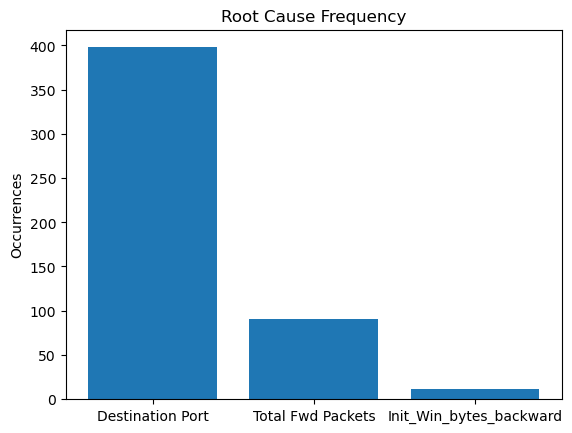

In [50]:
import matplotlib.pyplot as plt

plt.bar(cause_counts.keys(), cause_counts.values())

plt.title("Root Cause Frequency")

plt.ylabel("Occurrences")

plt.show()

In [39]:
sample = attacks.iloc[0]

ranking = explain_attack(sample)

print("Root Cause Ranking:")

for feature, score in ranking:
    print(feature, round(score,3))

Root Cause Ranking:
Destination Port 0.226
Init_Win_bytes_backward 0.187
Total Fwd Packets 0.074


In [40]:
for i in range(5):

    sample = attacks.iloc[i]

    print("\nAttack", i)

    ranking = explain_attack(sample)

    for feature, score in ranking:
        print(feature, round(score,3))


Attack 0
Destination Port 0.226
Init_Win_bytes_backward 0.187
Total Fwd Packets 0.074

Attack 1
Destination Port 0.226
Init_Win_bytes_backward 0.187
Total Fwd Packets 0.074

Attack 2
Destination Port 0.226
Init_Win_bytes_backward 0.187
Total Fwd Packets 0.074

Attack 3
Destination Port 0.226
Init_Win_bytes_backward 0.187
Total Fwd Packets 0.074

Attack 4
Total Fwd Packets 0.509
Destination Port 0.468
Init_Win_bytes_backward 0.455


Most Frequent root cause across attacks 


In [41]:
from collections import Counter

top_causes = []

for i in range(200):
    ranking = explain_attack(attacks.iloc[i])
    top_causes.append(ranking[0][0])

Counter(top_causes)

Counter({'Destination Port': 162,
         'Total Fwd Packets': 35,
         'Init_Win_bytes_backward': 3})

In [42]:
print(causal_features)


['Destination Port', 'Total Fwd Packets', 'Init_Win_bytes_backward']


In [44]:
sample = attacks.iloc[0]

ranking = explain_attack(sample)

print("Example Root Cause Analysis\n")

print("Attack detected\n")

print("Root Causes:")

for i,(feature,score) in enumerate(ranking,1):
    print(f"{i}. {feature} ({round(score,3)})")

Example Root Cause Analysis

Attack detected

Root Causes:
1. Destination Port (0.226)
2. Init_Win_bytes_backward (0.187)
3. Total Fwd Packets (0.074)


In [48]:
for i in range(6):

    print("\nAttack Example", i)

    ranking = explain_attack(attacks.iloc[i])

    for j,(feature,score) in enumerate(ranking,1):
        print(f"{j}. {feature} ({round(score,3)})")


Attack Example 0
1. Destination Port (0.226)
2. Init_Win_bytes_backward (0.187)
3. Total Fwd Packets (0.074)

Attack Example 1
1. Destination Port (0.226)
2. Init_Win_bytes_backward (0.187)
3. Total Fwd Packets (0.074)

Attack Example 2
1. Destination Port (0.226)
2. Init_Win_bytes_backward (0.187)
3. Total Fwd Packets (0.074)

Attack Example 3
1. Destination Port (0.226)
2. Init_Win_bytes_backward (0.187)
3. Total Fwd Packets (0.074)

Attack Example 4
1. Total Fwd Packets (0.509)
2. Destination Port (0.468)
3. Init_Win_bytes_backward (0.455)

Attack Example 5
1. Destination Port (0.226)
2. Init_Win_bytes_backward (0.187)
3. Total Fwd Packets (0.074)
